# Исследовательский анализ пользовательских предпочтений и проверка гипотез о поведении пользователей Яндекс Афиши в осенний период 2024 года.

### 1. Введение

1.1 Название проекта
Исследовательский анализ пользовательских предпочтений и проверка гипотез о поведении пользователей Яндекс Афиши в осенний период 2024 года.

1.2. Цели проекта
Выявить изменения в пользовательских предпочтениях осенью 2024 года

Определить популярность различных типов событий в осенний период

Проверить гипотезы о различиях в поведении пользователей мобильных и стационарных устройств


1.3. Задачи
Загрузка и предобработка данных

Исследовательский анализ данных (EDA)

Анализ временных трендов

Сравнение поведения пользователей разных типов устройств

Проверка статистических гипотез

Формулировка выводов и рекомендаций

### 2. Описание данных

2.1. Источники данных
final_tickets_orders_df.csv - данные о заказах билетов

Период: 01.06.2024 - 31.10.2024

Устройства: только mobile и desktop

final_tickets_events_df.csv - данные о мероприятиях

Исключены: фильмы (event_type_main != 'фильм')

Содержит информацию о городах, регионах, площадках

final_tickets_tenge_df.csv - курс тенге к рублю

Период: 2024 год

Используется для конвертации валюты

### 3. Структура проекта

Шаг 1. Загрузка данных и знакомство с ними
Загрузка трех датасетов: orders, events, currency

Проверка размеров, структуры, типов данных

Первичный осмотр данных и выявление потенциальных проблем

Формирование промежуточных выводов о качестве данных

Шаг 2. Предобработка данных и подготовка
Обработка пропусков (проверка на корректность выгрузки)

Анализ категориальных переменных и их нормализация

Анализ количественных переменных

Поиск и обработка дубликатов

Преобразование типов данных (даты/время)

Создание новых признаков

Шаг 3. Исследовательский анализ данных

3.1. Анализ распределения заказов по сегментам и сезонные изменения

3.2. Осенняя активность пользователей

3.3. Популярные события и партнёры

Шаг 4. Статистический анализ данных

Гипотеза 1: Среднее количество заказов на пользователя выше у mobile

Нулевая гипотеза: средние равны

Альтернативная: среднее mobile > среднее desktop

Гипотеза 2: Среднее время между заказами выше у mobile

Анализ столбца days_since_prev

Интерпретация результатов

Шаг 5. Общий вывод и рекомендации

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro

In [2]:
df_orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
df_events = pd.read_csv('/datasets/final_tickets_events_df.csv')
df_tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [3]:
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [5]:
df_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


### Предобработка данных

In [6]:
df_tenge['rate_per_1'] = df_tenge['curs'] / 100

In [7]:
df_orders = pd.merge(df_orders, df_tenge[['data', 'rate_per_1']], 
               left_on='created_dt_msk', right_on='data', how='left')

In [8]:
df_orders['revenue_rub'] = np.where(
    df_orders['currency_code'] == 'rub',
    df_orders['revenue'],
    df_orders['revenue'] * df_orders['rate_per_1']
)

In [9]:
len(df_orders)

290849

In [10]:
len(df_events)

22427

In [11]:
df_orders.duplicated().sum()

0

In [12]:
df_orders.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
data                         0
rate_per_1                   0
revenue_rub                  0
dtype: int64

В данных не обнаружено пропусков, кроме столбца days_since_prev, для которого пропуски не являются аномалией

In [13]:
df_orders['cinema_circuit'].unique()

array(['нет', 'Другое', 'Киномакс', 'КиноСити', 'Москино', 'ЦентрФильм'],
      dtype=object)

In [14]:
df_orders['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

In [15]:
for col in ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical']:
    print(f"{col}: {df_orders[col].unique()}")

cinema_circuit: ['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']
age_limit: [16  0 18 12  6]
currency_code: ['rub' 'kzt']
device_type_canonical: ['mobile' 'desktop']


In [16]:
df_events['event_type_main'].unique()

array(['театр', 'концерты', 'ёлки', 'другое', 'стендап', 'выставки',
       'спорт'], dtype=object)

In [17]:
df_orders['tickets_count'].unique()

array([ 4,  2,  3,  1,  5,  6, 10,  9,  7, 13, 15, 11,  8, 14, 12, 47, 27,
       17, 19, 57, 30, 37])

Дубликатов и явных ошибок не обнаружено. Данные готовы для дальнейшего анализа. Все категориальные переменные содержат логичные значения без явных аномалий

In [18]:
def analyze_numeric_column(df, column_name, title, currency=None):
    stats_df = df[column_name].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
    for p in [90, 95, 99, 99.5, 99.9]:
        value = df[column_name].quantile(p/100)
        print(f"{p} процентиль: {value:.2f}")
    return stats_df

In [19]:
def analyze_by_currency(df):
    revenue_rub = df[df['currency_code'] == 'rub']['revenue_rub']
    revenue_kzt = df[df['currency_code'] == 'kzt']['revenue_rub']
    analyze_numeric_column(df[df['currency_code'] == 'rub'], 'revenue_rub', 'Выручка в RUB')
    analyze_numeric_column(df[df['currency_code'] == 'kzt'], 'revenue_rub', 'Выручка в KZT (в рублях)')

In [20]:
analyze_by_currency(df_orders)

90 процентиль: 1276.15
95 процентиль: 1606.50
99 процентиль: 2569.59
99.5 процентиль: 2988.16
99.9 процентиль: 5140.78
90 процентиль: 2628.42
95 процентиль: 2742.08
99 процентиль: 3504.56
99.5 процентиль: 4191.43
99.9 процентиль: 4380.70


Между 99 и 99.9 процентилями в обеих группах есть значительная разница, значит, следует отобрать данные по 99 процентилю.

In [21]:
p99 = df_orders['revenue_rub'].quantile(0.99)
df_orders_filtered = df_orders[df_orders['revenue_rub'] <= p99].copy()
df_orders = df_orders_filtered
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,data,rate_per_1,revenue_rub
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN,2024-08-20,0.186972,1521.94
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN,2024-07-23,0.183419,289.45
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0,2024-10-06,0.196475,1258.57
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN,2024-07-13,0.185010,8.49
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0,2024-10-04,0.196648,1390.41


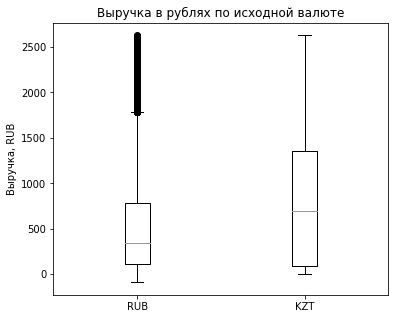

In [22]:
plt.figure(figsize=(6, 5))
plt.boxplot([df_orders[df_orders['currency_code'] == 'rub']['revenue_rub'],
             df_orders[df_orders['currency_code'] == 'kzt']['revenue_rub']],
            labels=['RUB', 'KZT'])
plt.title('Выручка в рублях по исходной валюте')
plt.ylabel('Выручка, RUB');

В рублевой валюте заметны сильные выбросы, которые в дальнейшем будут обработаны. В тенге основной разброс приходится от ~50 до ~1400

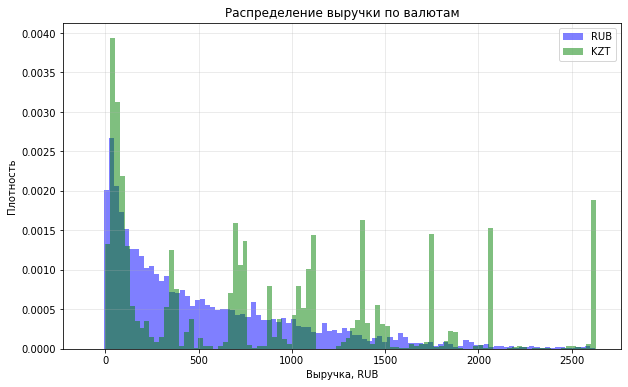

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
df_orders[df_orders['currency_code'] == 'rub']['revenue_rub'].hist(
    bins=100, alpha=0.5, label='RUB', ax=ax, color='blue', density=True)
df_orders[df_orders['currency_code'] == 'kzt']['revenue_rub'].hist(
    bins=100, alpha=0.5, label='KZT', ax=ax, color='green', density=True)

ax.set_title('Распределение выручки по валютам')
ax.set_xlabel('Выручка, RUB')
ax.set_ylabel('Плотность')
ax.legend()
ax.grid(True, alpha=0.3)

Можем заметить, что распределения рубля достаточно равномерно достигает пика от 0 до 100 рублей и постепенно снижает популярность стоимости, в то время как плотность распределения тенге оччень рваная.

#### Проверка неявных дубликатов
Проверим данные по основным столбцам 'user_id', 'event_id', 'created_ts_msk' (с точностью до времени), 'tickets_count', 'revenue'

In [24]:
dup_columns = ['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'revenue']
duplicates = df_orders[df_orders.duplicated(subset=dup_columns, keep=False)]
print(f"Найдено {len(duplicates)} неявных дубликатов")

Найдено 85 неявных дубликатов


Это может указывать на техническую ошибку сервиса либо двойное нажатие при оформлении билета

In [25]:
df_sorted = df_orders.sort_values('created_ts_msk')
df_clean = df_sorted.drop_duplicates(subset=dup_columns, keep='first')
removed_simple = len(df_orders) - len(df_clean)
print(f"  Удалено записей: {removed_simple}")
print(f"  Осталось записей: {len(df_clean)}")

  Удалено записей: 44
  Осталось записей: 287980


Теперь проверим данные по столбцам 'user_id', 'event_id', 'created_dt_msk' (только по дате), 'tickets_count', 'revenue',  'age_limit', 'currency_code', 'device_type_canonical'

In [26]:
dup_columns = ['user_id', 'event_id', 'created_dt_msk', 'tickets_count', 'revenue',  'age_limit', 'currency_code', 'device_type_canonical']
duplicates = df_clean[df_clean.duplicated(subset=dup_columns, keep=False)]
print(f"Найдено {len(duplicates)} неявных дубликатов")
df_orders = df_clean

Найдено 83345 неявных дубликатов


Неявных дубликатов по дням без учета времени получилось слишком много. Это может указывать на то, что пользователи докупали билеты, например, своим друзьям или родственникам, и ошибки в дублировании нет. Пользователи могут делать несколько заказов в один день.

In [27]:
df_orders.dtypes

order_id                   int64
user_id                   object
created_dt_msk            object
created_ts_msk            object
event_id                   int64
cinema_circuit            object
age_limit                  int64
currency_code             object
device_type_canonical     object
revenue                  float64
service_name              object
tickets_count              int64
total                    float64
days_since_prev          float64
data                      object
rate_per_1               float64
revenue_rub              float64
dtype: object

In [28]:
df_clean = df_orders.copy()
datetime_columns = ['created_dt_msk', 'created_ts_msk', 'data']
for col in datetime_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
df_orders = df_clean

In [29]:
#df_orders['revenue_rub'] = df_orders['revenue_rub'].astype('float64')

In [30]:
df_orders['one_ticket_revenue_rub']= df_orders['revenue_rub'] / df_orders['tickets_count']
df_orders['month'] = df_orders['created_dt_msk'].dt.month

season_map = {
1:'зима', 2:'зима', 12:'зима',
3:'весна', 4:'весна', 5:'весна', 
6: 'лето', 7: 'лето', 8: 'лето', 
9: 'осень', 10: 'осень', 11: 'осень'}
df_orders['season'] = df_orders['month'].map(season_map)

In [31]:
df_orders.dtypes

order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                          int64
currency_code                     object
device_type_canonical             object
revenue                          float64
service_name                      object
tickets_count                      int64
total                            float64
days_since_prev                  float64
data                      datetime64[ns]
rate_per_1                       float64
revenue_rub                      float64
one_ticket_revenue_rub           float64
month                              int64
season                            object
dtype: object

In [32]:
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,data,rate_per_1,revenue_rub,one_ticket_revenue_rub,month,season
285516,7565637,fd4d47438ebb946,2024-06-01,2024-06-01 00:00:42,131671,нет,12,rub,mobile,1083.15,Прачечная,4,12034.97,0.0,2024-06-01,0.202773,1083.15,270.787500,6,лето
285517,7565521,fd4d47438ebb946,2024-06-01,2024-06-01 00:01:30,131671,нет,12,rub,mobile,812.36,Прачечная,3,9026.23,0.0,2024-06-01,0.202773,812.36,270.786667,6,лето
118934,6670842,57ef0a1905ac488,2024-06-01,2024-06-01 00:01:58,375861,нет,12,rub,mobile,2091.31,Билеты в руки,4,20913.12,NaN,2024-06-01,0.202773,2091.31,522.827500,6,лето
285519,7565550,fd4d47438ebb946,2024-06-01,2024-06-01 00:03:13,131671,нет,12,rub,mobile,812.36,Прачечная,3,9026.23,0.0,2024-06-01,0.202773,812.36,270.786667,6,лето
264758,5502055,e73089d7d016cd8,2024-06-01,2024-06-01 00:03:34,211846,нет,12,rub,mobile,181.39,Прачечная,2,1813.91,0.0,2024-06-01,0.202773,181.39,90.695000,6,лето


In [33]:
df_orders['revenue'].min() # проверяем аномалии 

-90.76

In [34]:
df_orders['tickets_count'].min()

1

In [35]:
df_orders = df_orders[df_orders['revenue'] >= 0].copy()
df_orders['revenue'].min()

0.0

In [36]:
len(df_orders)

287599

#### Промежуточный вывод:

- Объединены датасеты заказов и курса валют по дате создания заказа
- Выручка приведена к единой валюте (рублям) через столбец revenue_rub
- Для заказов в тенге применен курс конвертации, для рублей оставлены исходные значения
- Выявлены значительные выбросы в данных - между 99 и 99.9 процентилями наблюдается большой разброс
- Принято решение отфильтровать данные по 99-му процентилю
- Найдено 85 неявных дубликатов при проверке по точному времени (created_ts_msk)
- Исправлен тип данных для revenue_rub с object на float64
- Преобразованы столбцы с датами в тип datetime64[ns]
- Длина датасета с заказами ссоставляет  290805 строк

### Исследовательсикй анализ
#### Анализ распределения заказов по сегментам и их сезонные изменения


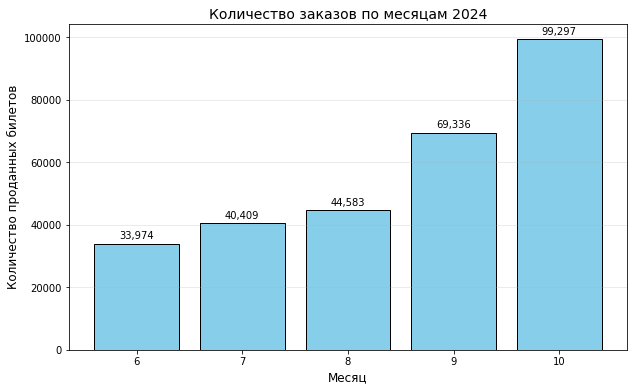

In [37]:
orders_by_month = df_orders['month'].value_counts().sort_index()
plt.figure(figsize = (10,6))
plt.bar(orders_by_month.index, orders_by_month.values, color = 'skyblue', edgecolor='black')
plt.title('Количество заказов по месяцам 2024' ,fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество проданных билетов', fontsize=12)
plt.grid(axis='y', alpha=0.3)
for month, count in orders_by_month.items():
    plt.text(month, count + 1000, f'{count:,}', 
             ha='center', va='bottom', fontsize=10);


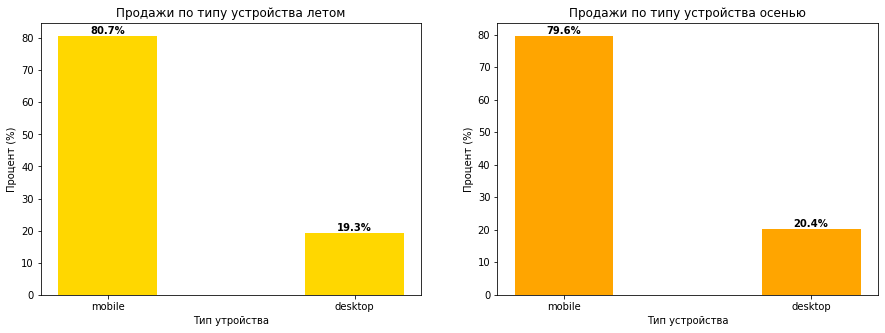

In [38]:
df_merged = pd.merge(df_orders,df_events, on = 'event_id', how = 'left')
summer = df_merged[df_merged['season'] == 'лето']
autumn = df_merged[df_merged['season'] == 'осень']

summer_dev = summer['device_type_canonical'].value_counts(normalize=True) * 100
autumn_dev = autumn['device_type_canonical'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
summer_bars = axes[0].bar(summer_dev.index, summer_dev.values, width=0.4, label='Лето', color='gold')
autumn_bars = axes[1].bar(autumn_dev.index, autumn_dev.values, width=0.4, label='Осень', color='orange')
axes[0].set_title('Продажи по типу устройства летом')
axes[1].set_title('Продажи по типу устройства осенью')
axes[0].set_ylabel('Процент (%)')
axes[1].set_ylabel('Процент (%)')
axes[0].set_xlabel('Тип утройства')
axes[1].set_xlabel('Тип устройства')
def add_value_labels(ax, bars, fmt='{:.1f}%'):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                fmt.format(height), ha='center', va='bottom', fontsize=10, fontweight='bold')
add_value_labels(axes[0], summer_bars)
add_value_labels(axes[1], autumn_bars)

summer_age = summer['age_limit'].value_counts(normalize=True) * 100
autumn_age = autumn['age_limit'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
summer_bars = axes[0].bar(summer_age.index, summer_age.values, width=0.4, label='Лето', color='gold')
autumn_bars = axes[1].bar(autumn_age.index, autumn_age.values, width=0.4, label='Осень', color='orange')
axes[0].set_title('Продажи по возрастной категории летом')
axes[1].set_title('Продажи по возрастной категории осенью')
axes[0].set_ylabel('Процент (%)')
axes[1].set_ylabel('Процент (%)')
axes[0].set_xlabel('Возрастная категория')
axes[1].set_xlabel('Возрастная категория')
def add_value_labels(ax, bars, fmt='{:.1f}%'):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                fmt.format(height), ha='center', va='bottom', fontsize=10, fontweight='bold')
add_value_labels(axes[0], summer_bars)
add_value_labels(axes[1], autumn_bars)

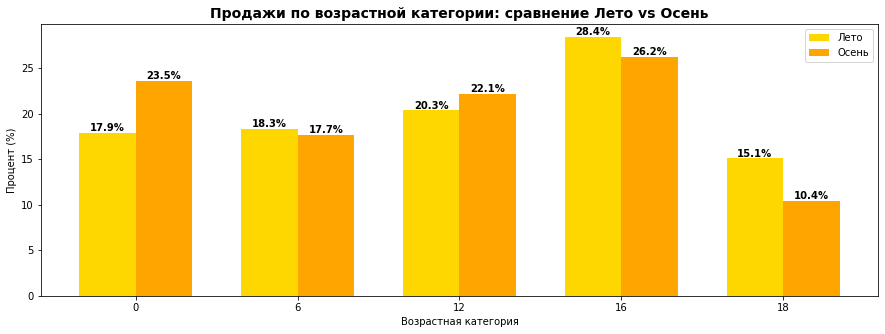

In [39]:
summer_age = summer['age_limit'].value_counts(normalize=True) * 100
autumn_age = autumn['age_limit'].value_counts(normalize=True) * 100

age_comparison = pd.DataFrame({
    'Лето': summer_age,
    'Осень': autumn_age
}).fillna(0)
width = 0.35
age_comparison = age_comparison.sort_index()
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(age_comparison))
summer_bars = ax.bar(x - width/2, age_comparison['Лето'], width, 
                     label='Лето', color='gold')
autumn_bars = ax.bar(x + width/2, age_comparison['Осень'], width, 
                     label='Осень', color='orange')
ax.set_title('Продажи по возрастной категории: сравнение Лето vs Осень', 
             fontweight='bold', fontsize=14)
ax.set_ylabel('Процент (%)')
ax.set_xlabel('Возрастная категория')
ax.set_xticks(x)
ax.set_xticklabels(age_comparison.index)
ax.legend()
def add_value_labels(ax, bars, fmt='{:.1f}%'):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                fmt.format(height), ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
add_value_labels(ax, summer_bars)
add_value_labels(ax, autumn_bars)

summer_ev = summer['event_type_main'].value_counts(normalize=True) * 100
autumn_ev = autumn['event_type_main'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
summer_bars = axes[0].bar(summer_ev.index, summer_ev.values, width=0.4, label='Лето', color='gold')
autumn_bars = axes[1].bar(autumn_ev.index, autumn_ev.values, width=0.4, label='Осень', color='orange')
axes[0].set_title('Продажи по типу мероприятия летом', fontweight='bold')
axes[1].set_title('Продажи по типу мероприятия осенью', fontweight='bold')
axes[0].set_ylabel('Процент (%)')
axes[1].set_ylabel('Процент (%)')
axes[0].set_xlabel('Тип мероприятия')
axes[1].set_xlabel('Тип мероприятия')
def add_value_labels(ax, bars, fmt='{:.1f}%'):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                fmt.format(height), ha='center', va='bottom', fontsize=10, fontweight='bold')
add_value_labels(axes[0], summer_bars)
add_value_labels(axes[1], autumn_bars)

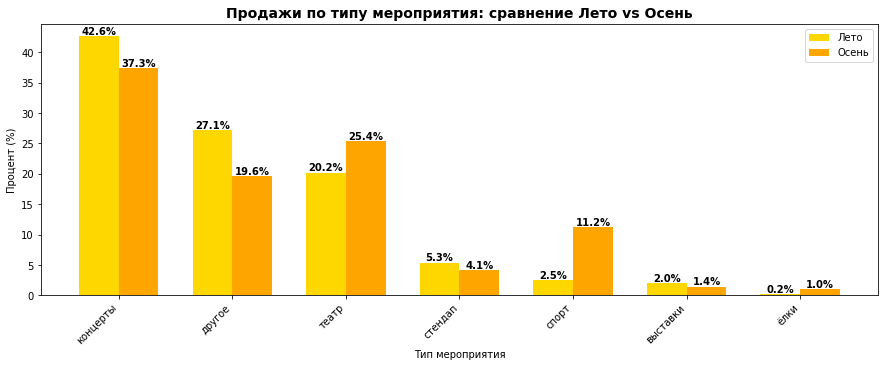

In [40]:
summer_ev = summer['event_type_main'].value_counts(normalize=True) * 100
autumn_ev = autumn['event_type_main'].value_counts(normalize=True) * 100
ev_comparison = pd.DataFrame({
    'Лето': summer_ev,
    'Осень': autumn_ev
}).fillna(0)
ev_comparison = ev_comparison.sort_values('Лето', ascending=False)
fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(ev_comparison))
summer_bars = ax.bar(x - width/2, ev_comparison['Лето'], width, 
                     label='Лето', color='gold')
autumn_bars = ax.bar(x + width/2, ev_comparison['Осень'], width, 
                     label='Осень', color='orange')
ax.set_title('Продажи по типу мероприятия: сравнение Лето vs Осень', 
             fontweight='bold', fontsize=14)
ax.set_ylabel('Процент (%)')
ax.set_xlabel('Тип мероприятия')
ax.set_xticks(x)
ax.set_xticklabels(ev_comparison.index, rotation=45, ha='right')
ax.legend()
add_value_labels(ax, summer_bars)
add_value_labels(ax, autumn_bars)

In [41]:
season_event_revenue = df_merged.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().reset_index()
revenue_pivot = season_event_revenue.pivot(index='event_type_main',
    columns='season', values='one_ticket_revenue_rub').reset_index()

In [42]:
for col in revenue_pivot.columns:
        if col != 'event_type_main':
            revenue_pivot[col] = revenue_pivot[col].round(2)
revenue_pivot

season,event_type_main,лето,осень
0,выставки,86.74,91.91
1,другое,77.83,76.48
2,концерты,302.34,269.32
3,спорт,50.81,50.02
4,стендап,218.59,231.47
5,театр,214.40,176.24
6,ёлки,271.44,230.31


##### Промежуточный вывод
- Количество заказов стремительно возрастает с июня по ноябрь.
- Независимо от сезона, с мобильного телефона совершается абсолютное большинство покупок (около 80%).
- Наиболее популярна летом категория 16+ (28,4%), вероятно из-за того, что у школьников и студентов, которые могут гулять без сопровождения родителей, каникулы.
- Осенью так же остается популярной категория 16+ (26,2%), но ее догоняет категория универсальных мероприятий 0+ (23,6%)
- Продажи по типу мероприятий летом и осенью почти не различаются , по популярности идут: концерты (42% и 37% соответственно), театр (20,1% и 25,3%), другое (27,2% и 19,7%), наименее популярны билеты на елки летом и осенью, что вполне очевидно.
- Средняя цена билета осенью снизилась по сравнению с летом у большинства категорий мероприятий.
- Наибольшее падение цен наблюдается в категориях: театр, ёлки, концерты 
- Рост цен зафиксирован только у: стендап, выставки
- Цены остались стабильными на спортивные мероприятия и категорию другое

#### Осенняя активность пользователей

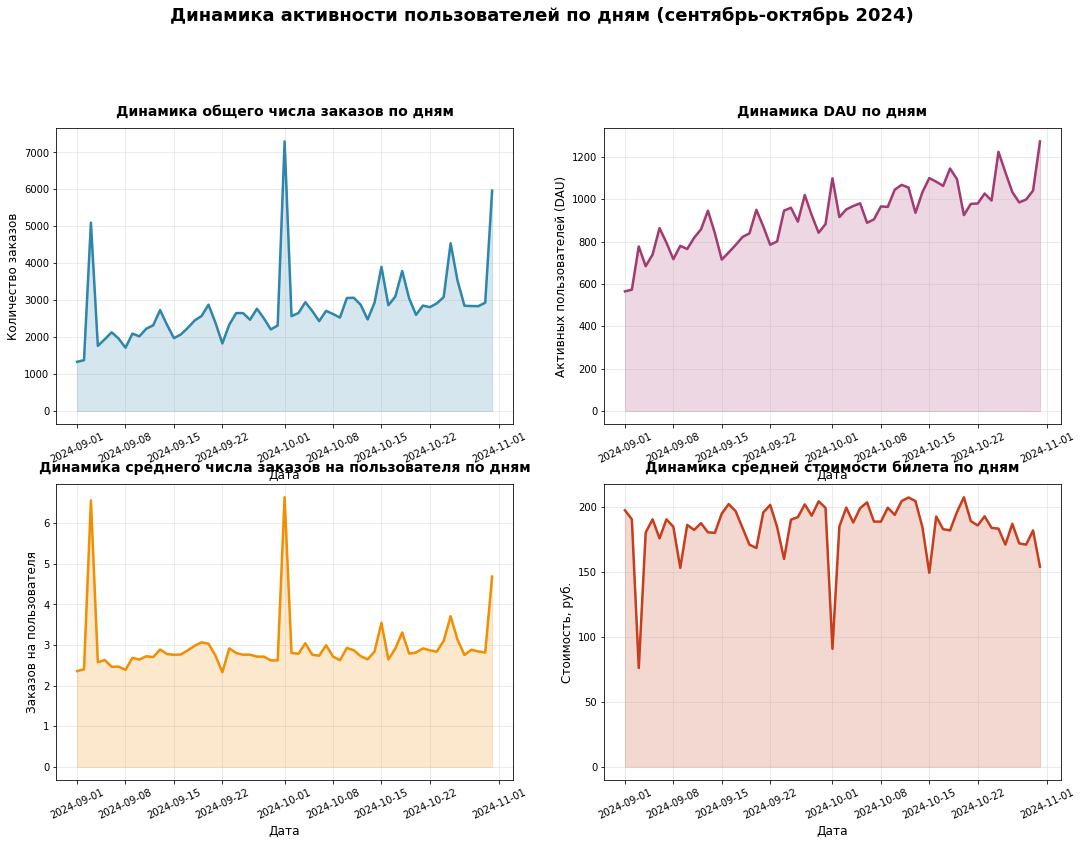

In [43]:
daily = df_merged.groupby('created_dt_msk').agg(
    total_orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    total_tickets=('tickets_count', 'sum'),
    total_revenue=('revenue_rub', 'sum')
)
daily['avg_ticket_revenue_rub'] = daily['total_revenue'] / daily['total_tickets']
daily['avg_orders_per_person'] = daily['total_orders'] / daily['dau']
daily.index = pd.to_datetime(daily.index)
autumn_2024 = daily[(daily.index >= '2024-09-01') & (daily.index <= '2024-10-31')].copy()
fig_dynamics, axes_dynamics = plt.subplots(2, 2, figsize=(18, 12))
fig_dynamics.suptitle('Динамика активности пользователей по дням (сентябрь-октябрь 2024)', fontsize=18, fontweight='bold', y=1.02)
# 2.1 Общее число заказов
axes_dynamics[0, 0].plot(autumn_2024.index, autumn_2024['total_orders'], color='#2E86AB', linewidth=2.5)
axes_dynamics[0, 0].set_title('Динамика общего числа заказов по дням', fontsize=14, fontweight='bold', pad=12)
axes_dynamics[0, 0].set_ylabel('Количество заказов', fontsize=12)
axes_dynamics[0, 0].set_xlabel('Дата', fontsize=12)
axes_dynamics[0, 0].grid(True, alpha=0.3)
axes_dynamics[0, 0].tick_params(axis='x', rotation=25)
axes_dynamics[0, 0].fill_between(autumn_2024.index, autumn_2024['total_orders'], alpha=0.2, color='#2E86AB')
# DAU 
axes_dynamics[0, 1].plot(autumn_2024.index, autumn_2024['dau'], color='#A23B72', linewidth=2.5)
axes_dynamics[0, 1].set_title('Динамика DAU по дням', fontsize=14, fontweight='bold', pad=12)
axes_dynamics[0, 1].set_ylabel('Активных пользователей (DAU)', fontsize=12)
axes_dynamics[0, 1].set_xlabel('Дата', fontsize=12)
axes_dynamics[0, 1].grid(True, alpha=0.3)
axes_dynamics[0, 1].tick_params(axis='x', rotation=25)
axes_dynamics[0, 1].fill_between(autumn_2024.index, autumn_2024['dau'], alpha=0.2, color='#A23B72')
# Среднее число заказов на пользователя 
axes_dynamics[1, 0].plot(autumn_2024.index, autumn_2024['avg_orders_per_person'], color='#F18F01', linewidth=2.5)
axes_dynamics[1, 0].set_title('Динамика среднего числа заказов на пользователя по дням', fontsize=14, fontweight='bold', pad=12)
axes_dynamics[1, 0].set_ylabel('Заказов на пользователя', fontsize=12)
axes_dynamics[1, 0].set_xlabel('Дата', fontsize=12)
axes_dynamics[1, 0].grid(True, alpha=0.3)
axes_dynamics[1, 0].tick_params(axis='x', rotation=25)
axes_dynamics[1, 0].fill_between(autumn_2024.index, autumn_2024['avg_orders_per_person'], alpha=0.2, color='#F18F01')
# Средняя стоимость билета
axes_dynamics[1, 1].plot(autumn_2024.index, autumn_2024['avg_ticket_revenue_rub'], color='#C73E1D', linewidth=2.5)
axes_dynamics[1, 1].set_title('Динамика средней стоимости билета по дням', fontsize=14, fontweight='bold', pad=12)
axes_dynamics[1, 1].set_ylabel('Стоимость, руб.', fontsize=12)
axes_dynamics[1, 1].set_xlabel('Дата', fontsize=12)
axes_dynamics[1, 1].grid(True, alpha=0.3)
axes_dynamics[1, 1].tick_params(axis='x', rotation=25)
axes_dynamics[1, 1].fill_between(autumn_2024.index, autumn_2024['avg_ticket_revenue_rub'], alpha=0.2, color='#C73E1D');

In [44]:
autumn_2024['day_of_week'] = autumn_2024.index.day_name()
weekly_stats = autumn_2024.groupby('day_of_week').agg({
    'total_orders': 'mean',
    'dau': 'mean', 
    'avg_orders_per_person': 'mean',
    'avg_ticket_revenue_rub': 'mean'
}).reset_index()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_stats['day_of_week'] = pd.Categorical(weekly_stats['day_of_week'], categories=day_order, ordered=True)
weekly_stats = weekly_stats.sort_values('day_of_week')

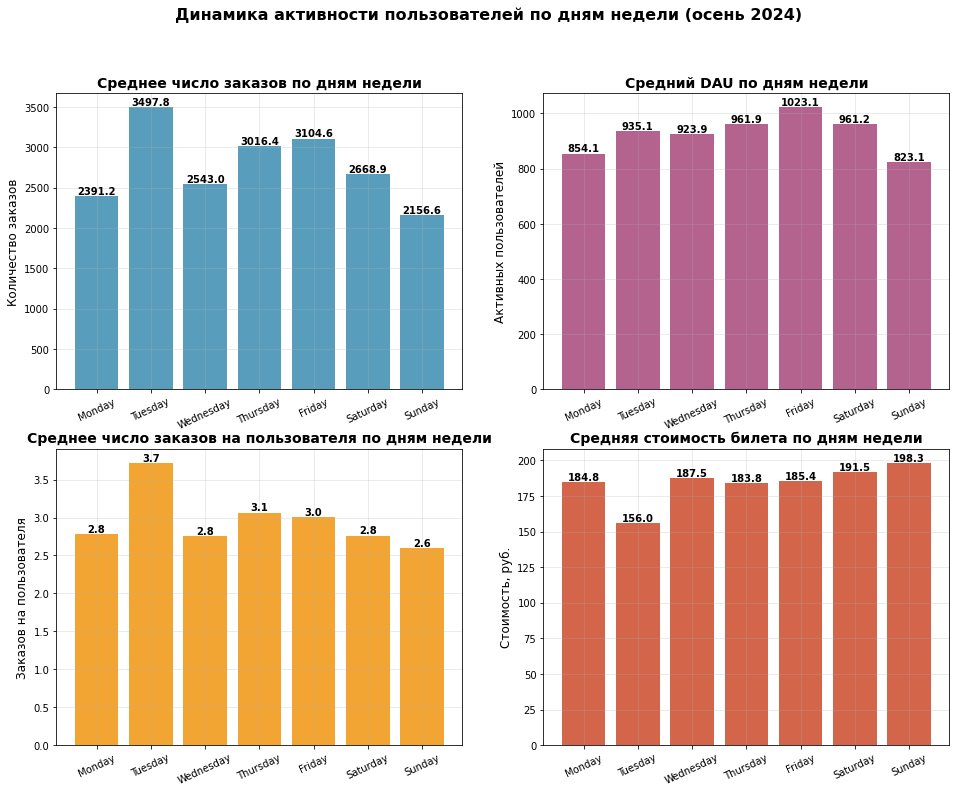

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Динамика активности пользователей по дням недели (осень 2024)', fontsize=16, fontweight='bold')
x = range(len(weekly_stats))
x_labels = weekly_stats['day_of_week']
# 1 Общее число заказов
axes[0, 0].bar(x, weekly_stats['total_orders'], color='#2E86AB', alpha=0.8)
axes[0, 0].set_title('Среднее число заказов по дням недели', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Количество заказов', fontsize=12)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(x_labels, rotation=25)
axes[0, 0].grid(True, alpha=0.3)
# 2 DAU
axes[0, 1].bar(x, weekly_stats['dau'], color='#A23B72', alpha=0.8)
axes[0, 1].set_title('Средний DAU по дням недели', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Активных пользователей', fontsize=12)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(x_labels, rotation=25)
axes[0, 1].grid(True, alpha=0.3)
# 3 Заказы на пользователя
axes[1, 0].bar(x, weekly_stats['avg_orders_per_person'], color='#F18F01', alpha=0.8)
axes[1, 0].set_title('Среднее число заказов на пользователя по дням недели', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Заказов на пользователя', fontsize=12)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(x_labels, rotation=25)
axes[1, 0].grid(True, alpha=0.3)
# 4 Средняя стоимость билета
axes[1, 1].bar(x, weekly_stats['avg_ticket_revenue_rub'], color='#C73E1D', alpha=0.8)
axes[1, 1].set_title('Средняя стоимость билета по дням недели', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Стоимость, руб.', fontsize=12)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(x_labels, rotation=25)
axes[1, 1].grid(True, alpha=0.3)

def add_bar_labels(ax, values):
    for i, v in enumerate(values):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
add_bar_labels(axes[0, 0], weekly_stats['total_orders'])
add_bar_labels(axes[0, 1], weekly_stats['dau'])
add_bar_labels(axes[1, 0], weekly_stats['avg_orders_per_person'])
add_bar_labels(axes[1, 1], weekly_stats['avg_ticket_revenue_rub'])

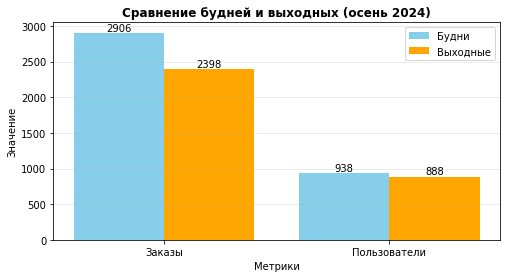

In [46]:
autumn_2024['is_weekend'] = autumn_2024.index.weekday >= 5 
weekdays = autumn_2024[~autumn_2024['is_weekend']]
weekends = autumn_2024[autumn_2024['is_weekend']]
weekday_avg = weekdays.mean(numeric_only=True)
weekend_avg = weekends.mean(numeric_only=True)

plt.figure(figsize=(8, 4))
metrics = ['Заказы', 'Пользователи']
values_weekday = [weekday_avg['total_orders'], weekday_avg['dau']]
values_weekend = [weekend_avg['total_orders'], weekend_avg['dau']]
x = range(len(metrics))
width = 0.4
bars1 = plt.bar([i - width/2 for i in x], values_weekday, width=width, label='Будни', color='skyblue')
bars2 = plt.bar([i + width/2 for i in x], values_weekend, width=width, label='Выходные', color='orange')
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.xticks(x, metrics)
plt.title('Сравнение будней и выходных (осень 2024)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars1, values_weekday):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{value:.0f}', 
             ha='center', va='bottom')
for bar, value in zip(bars2, values_weekend):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{value:.0f}', 
             ha='center', va='bottom')

##### Промежуточный вывод
- Наблюдается устойчивый рост активности пользователей с сентября по ноябрь 2024 года, при этом стоимость билетов по дням не сильно различается.
- Пик активности закаков приходился на начало сентября и октября, при этом стоимость билетов в эти даты была аномально низкой, возможно проводились общественные бесплатные мероприятия, которые привлекли большое количество участников
- Пользователи наиболее активны в будни - люди планируют развлечения на выходные в начале недели, заранее
- Наблюдается не только количественный рост, но и качественное улучшение - пользователи становятся более вовлеченными и чаще совершают покупки.
- Количество пользователей в будни всего на 50 больше, чем в выходные. При этом заказы совершаются чаще в будни в среднем на 302. Вероятно люди планируют активности на выходные во время рабочей недели, поэтому покупают билеты заранее.
- Во вторник могла проводиться какая либ акция, в связи с чем спрос на покупку билетов резко возрос.
- Аномальные продажи прошлись на 3 сентября 2024 и 1 октября 2024, в эти дни продажи билетов достигли своих пиков, при том, что цены на билеты были очень низкими (ниже 100 рублей в среднем). К тому же в эти дни пользователи покупали максимальное кол-во билетов на человека (больше 6 в среднем).

#### Популярные события и партнёры

In [47]:
df_merged.head(2)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,7565637,fd4d47438ebb946,2024-06-01,2024-06-01 00:00:42,131671,нет,12,rub,mobile,1083.15,...,f4431442-3d97-452d-a6d6-eadf6bd34378,спектакль,театр,№3734,Каменевский регион,Глиногорск,213.0,4019.0,"Группа исследователей искусства ""Сказка"" Лтд","алл. Шаумяна, д. 48 стр. 584"
1,7565521,fd4d47438ebb946,2024-06-01,2024-06-01 00:01:30,131671,нет,12,rub,mobile,812.36,...,f4431442-3d97-452d-a6d6-eadf6bd34378,спектакль,театр,№3734,Каменевский регион,Глиногорск,213.0,4019.0,"Группа исследователей искусства ""Сказка"" Лтд","алл. Шаумяна, д. 48 стр. 584"


In [57]:
grouped_by_region = df_merged.groupby('region_name').agg(
events_count = ('event_name', 'nunique'),
orders_total = ('order_id', 'count'))

total_events = grouped_by_region['events_count'].sum()
total_orders = grouped_by_region['orders_total'].sum()
grouped_by_region['events_parted'] = round(grouped_by_region['events_count'] / total_events * 100,2)
grouped_by_region['orders_parted'] = round(grouped_by_region['orders_total'] / total_orders * 100,2)

grouped_by_region.sort_values('events_parted', ascending=False)

,events_count,orders_total,events_parted,orders_parted
region_name,,,,
Каменевский регион,4751,89744,24.86,31.23
Североярская область,3194,43737,16.71,15.22
Светополянский округ,990,7486,5.18,2.61
Широковская область,986,16102,5.16,5.60
Речиновская область,652,6266,3.41,2.18
...,...,...,...,...
Теплоозёрский округ,2,7,0.01,0.00
Сосноводолинская область,2,10,0.01,0.00
Лесноярский край,2,19,0.01,0.01


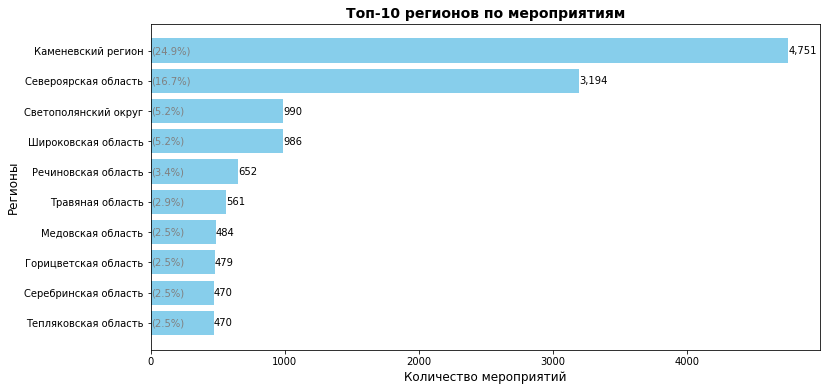

In [49]:
plt.figure(figsize = (12,6))
top_10 = grouped_by_region.nlargest(10, 'events_count')
bars = plt.barh(range(len(top_10)), top_10['events_count'], color='skyblue')
plt.yticks(range(len(top_10)), top_10.index) 
plt.xlabel('Количество мероприятий',fontsize=12 )
plt.title('Топ-10 регионов по мероприятиям', fontsize=14, fontweight='bold')
plt.ylabel('Регионы', fontsize=12)
plt.gca().invert_yaxis()  
for i, (bar, value) in enumerate(zip(bars, top_10['events_count'])):
    plt.text(value + 1, bar.get_y() + bar.get_height()/2, 
             f'{value:,}', va='center')
    part = (value / total_events * 100).round(1)
    plt.text(5, bar.get_y() + bar.get_height()/2, 
             f'({part}%)', va='center', color='gray')

In [50]:
partners_df = df_merged.groupby('service_name').agg(
events_count = ('event_name', 'nunique'),
orders_total = ('order_id', 'count'),
sum_revenue = ('revenue_rub', 'sum'))
total_sum = partners_df['sum_revenue'].sum()
partners_df['total_revenue_parted'] = round(partners_df['sum_revenue'] / total_sum * 100,4)
partners_df.sort_values('total_revenue_parted', ascending=False)

,events_count,orders_total,sum_revenue,total_revenue_parted
service_name,,,,
Билеты без проблем,3132,63025,2.485426e+07,16.6732
Мой билет,1031,34141,2.106189e+07,14.1291
Облачко,1762,26410,1.860930e+07,12.4838
Лови билет!,3851,40787,1.672857e+07,11.2222
Весь в билетах,688,16437,1.656600e+07,11.1131
Билеты в руки,2932,40208,1.320434e+07,8.8580
Край билетов,233,6118,6.429182e+06,4.3129
Прачечная,874,10222,4.746811e+06,3.1843
Дом культуры,231,4428,4.400413e+06,2.9520


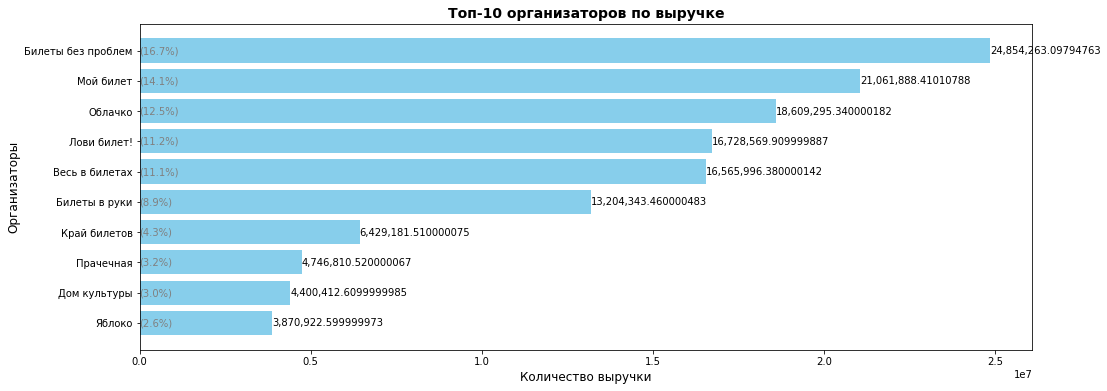

In [51]:
plt.figure(figsize = (16,6))
top_10_org = partners_df.nlargest(10, 'sum_revenue')
bars = plt.barh(range(len(top_10_org)), top_10_org['sum_revenue'], color='skyblue')
plt.yticks(range(len(top_10_org)), top_10_org.index) 
plt.xlabel('Количество выручки',fontsize=12 )
plt.ylabel('Организаторы', fontsize=12)
plt.title('Топ-10 организаторов по выручке', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  
for i, (bar, value) in enumerate(zip(bars, top_10_org['sum_revenue'])):
    plt.text(value + 1, bar.get_y() + bar.get_height()/2, 
             f'{value:,}', va='center')
    part = (value / total_sum * 100).round(1)
    plt.text(5, bar.get_y() + bar.get_height()/2, 
             f'({part}%)', va='center', color='gray')


##### Промежуточный вывод
- Явным лидером среди провеедния мероприятий по регионам является Камневский (24,9% от всех), 4751 за рассматриваемый период. Немного отстает Североярская область, 3194 мероприятия за период. Остальные регионы провели меньше 1000 мероприятий.
- Каменевский регион критически важен (25% активности)
- Среди билетных партнеров по выручке с мероприятий явно обгоняет всех "Билеты без проблем", занимая 16,7% от выручки со всех мероприятий. Немного отстает "Мой билет" (14,1%) и Облачко (12,5%). Остальные партнеры набирают 11% и меньше продаж билетов.
- Зависимость от трех партнеров: 43.3% выручки зависят от "Билеты без проблем", "Мой билет" и "Облачко"
- Рекомендация: развитие партнеров среднего эшелона для снижения зависимости от лидеров и изучение опыта высокомаржинальных партнеров для повышения средней выручки

### Статистический анализ данных

In [52]:
user_orders = autumn.groupby(['user_id', 'device_type_canonical']).agg(order_count=('order_id', 'count')).reset_index()
mobile_orders = user_orders[user_orders['device_type_canonical'] == 'mobile']
desktop_orders = user_orders[user_orders['device_type_canonical'] == 'desktop']

Сформулируем Н0 и Н1 для осеннего распределения продаж между мобильными и десктопными устройствами:

- Н0:  Среднее количество заказов на пользователя для мобильных утройств не больше, чем для десктопных устройств
- Н1:  Среднее количество заказов на пользователя мобильных устройств выше, чем для десктопных

In [53]:
mobile_users = set(mobile_orders['user_id'])
desktop_users = set(desktop_orders['user_id'])
intersection_users = mobile_users & desktop_users
#убираем пересечения
mobile_orders_clean = mobile_orders[~mobile_orders['user_id'].isin(intersection_users)].copy()
desktop_orders_clean = desktop_orders[~desktop_orders['user_id'].isin(intersection_users)].copy()

mobile_sample = mobile_orders_clean['order_count'].sample(min(5000, len(mobile_orders_clean)))
desktop_sample = desktop_orders_clean['order_count'].sample(min(5000, len(desktop_orders_clean)))

stat_mobile, p_mobile = shapiro(mobile_sample)
stat_desktop, p_desktop = shapiro(desktop_sample)

print(f"Тест нормальности Шапиро-Уилка:")
print(f"Мобильные: p-value = {p_mobile:.6f} {'(нормальное)' if p_mobile > 0.05 else '(не нормальное)'}")
print(f"Десктоп: p-value = {p_desktop:.6f} {'(нормальное)' if p_desktop > 0.05 else '(не нормальное)'}")

if p_mobile < 0.05 or p_desktop < 0.05:
    print(f"Распределение ненормальное - используем U-тест Манна-Уитни. Не требует нормальности распределения. Устойчив к выбросам и асимметрии")
    test_type = "U-тест Манна-Уитни"
else:
    print(f"Распределение нормальное - используем t-тест")
    test_type = "t-тест"

u_stat, u_p_value = stats.mannwhitneyu(
    mobile_orders_clean['order_count'],
    desktop_orders_clean['order_count'],
    alternative='greater'
)
alpha = 0.05
if u_p_value >= alpha:
    print('Принимаем нулевую гипотезу. Среднее количество заказов на пользователя для мобильных утройств не больше, чем для десктопных устройств'
         )
else:  
    print('Отвергаем нулевую гипотезу. Среднее количество заказов на пользователя мобильных устройств выше, чем для десктопных')

Тест нормальности Шапиро-Уилка:
Мобильные: p-value = 0.000000 (не нормальное)
Десктоп: p-value = 0.000000 (не нормальное)
Распределение ненормальное - используем U-тест Манна-Уитни. Не требует нормальности распределения. Устойчив к выбросам и асимметрии
Отвергаем нулевую гипотезу. Среднее количество заказов на пользователя мобильных устройств выше, чем для десктопных


Пользователи мобильных устройств совершают статистически значимо больше заказов на одного пользователя по сравнению с пользователями десктопных устройств. Это может быть связано с:
- Удобством мобильного приложения
- Возможностью быстрых покупок "на ходу"

Сформулируем Н0 и Н1 для осеннего распределения времени между заказами на мобильных и десктопных устройствах:

- Н0: Среднее время между заказами пользователя для мобильных устройств не меньше, чем для десктопных
- Н1: Среднее время между заказами пользователя мобильных устройств меньше, чем для десктопных

In [54]:
aurumn_sorted = autumn.sort_values(['user_id', 'created_ts_msk'])
aurumn_sorted['time_diff'] = aurumn_sorted.groupby('user_id')['created_ts_msk'].diff()
aurumn_sorted['time_diff'] = aurumn_sorted['time_diff'].dt.total_seconds() / 3600 # в часах
time_diff_data = aurumn_sorted.dropna(subset=['time_diff']) #убираем NaN

mobile_time = time_diff_data[time_diff_data['device_type_canonical'] == 'mobile']
desktop_time = time_diff_data[time_diff_data['device_type_canonical'] == 'desktop']
mobile_time_users = set(mobile_time['user_id'].unique())
desktop_time_users = set(desktop_time['user_id'].unique())
time_intersection_users = mobile_time_users & desktop_time_users
mobile_time_clean = mobile_time[~mobile_time['user_id'].isin(time_intersection_users)].copy()
desktop_time_clean = desktop_time[~desktop_time['user_id'].isin(time_intersection_users)].copy()

mobile_time_sample = mobile_time_clean['time_diff'].sample(min(5000, len(mobile_time_clean)))
desktop_time_sample = desktop_time_clean['time_diff'].sample(min(5000, len(desktop_time_clean)))
stat_mobile_time, p_mobile_time = shapiro(mobile_time_sample)
stat_desktop_time, p_desktop_time = shapiro(desktop_time_sample)
print(f"Мобильные: p-value = {p_mobile_time:.6f} {'(нормальное)' if p_mobile_time > 0.05 else '(не нормальное)'}")
print(f"Десктоп: p-value = {p_desktop_time:.6f} {'(нормальное)' if p_desktop_time > 0.05 else '(не нормальное)'}")
if p_mobile_time < 0.05 or p_desktop_time < 0.05:
    print(f"Распределение ненормальное → используем U-тест Манна-Уитни. U-тест не требует нормальности, устойчив к выбросам")
else:
    print(f"Распределение нормальное → используем t-тест")

stat2, p_value2 = stats.mannwhitneyu(
    mobile_time_clean['time_diff'],
    desktop_time_clean['time_diff'],
    alternative='less' 
)

if p_value2 >= alpha:
    print('Принимаем нулевую гипотезу. Среднее время между заказами пользователя для мобильных устройств не меньше, чем для десктопных')
else:
    print('Отвергаем нулевую гипотезу. Среднее время между заказами пользователя мобильных устройств меньше, чем для десктопных')

Мобильные: p-value = 0.000000 (не нормальное)
Десктоп: p-value = 0.000000 (не нормальное)
Распределение ненормальное → используем U-тест Манна-Уитни. U-тест не требует нормальности, устойчив к выбросам
Принимаем нулевую гипотезу. Среднее время между заказами пользователя для мобильных устройств не меньше, чем для десктопных


Среднее время между заказами пользователя мобильных устройств ниже,  значит пользователи мобильных устройств совершают покупки чаще. 

Мобильные пользователи демонстрируют более высокую и частую активность - они не только совершают больше покупок в расчете на пользователя, но и делают это чаще, с меньшими интервалами между заказами.

 Рекомендация для продуктового отдела: 
Сфокусироваться на развитии мобильного канала как наиболее перспективного с точки зрения пользовательской вовлеченности и частоты взаимодействия.

### Заключение

Анализируемый период: июнь-октябрь 2024 года
Объем данных: 290,805 заказов до очистки
Источники: заказы билетов, информация о мероприятиях, курс валют

Методология включала предобработку данных, конвертацию валют, удаление выбросов (по 99-му процентилю), анализ сезонных изменений и проверку статистических гипотез.

Популярность мероприятий

- Лидеры: Концерты (37-42%) и театр (20-25%)
- Осенние изменения: Рост театра, снижение концертов
- Цены: Падение осенью у большинства категорий, кроме стендапа (+6%)

Пользовательская активность

- Мобильное доминирование: 80% заказов с телефонов
- Высокая активность мобильных пользователей:
- Больше заказов на пользователя
- Меньше времени между заказами (покупки чаще)

Рост активности: Устойчивый рост с июня по октябрь

География и партнеры
- Регион-лидер: Каменевский (25% мероприятий)
- Партнер-лидер:"Билеты без проблем", занимая 16,7% от выручки
- Высокая концентрация: 5 регионов дают 80% мероприятий

Рекомендации: 
1. Приоритет мобильного канала. Усилить развитие приложения. Внедрить персонализированные предложения.
2. Сезонная адаптация: Внедрить динамическое ценообразование. Создать спецпредложения для категорий с падением спроса.
3. Региональный фокус: Укрепить позиции в Каменевском регионе. Усилить партнерства с топ-организаторами.

Мобильные пользователи - ключевая аудитория с высокой активностью. Успех зависит от развития мобильного канала, адаптации к сезонности и укрепления позиций в регионах-лидерах.